=== MODEL PERFORMANCE ===
              precision    recall  f1-score   support

    Unfunded       0.61      0.54      0.57       839
      Funded       0.80      0.84      0.82      1820

    accuracy                           0.74      2659
   macro avg       0.70      0.69      0.69      2659
weighted avg       0.74      0.74      0.74      2659


=== PROCESS COMPLETE ===
Generated expert review list for 265 high-risk projects
Saved files:
- DonorsChoose_Expert_Review_List.csv
- probability_distribution.png
- feature_importance.png


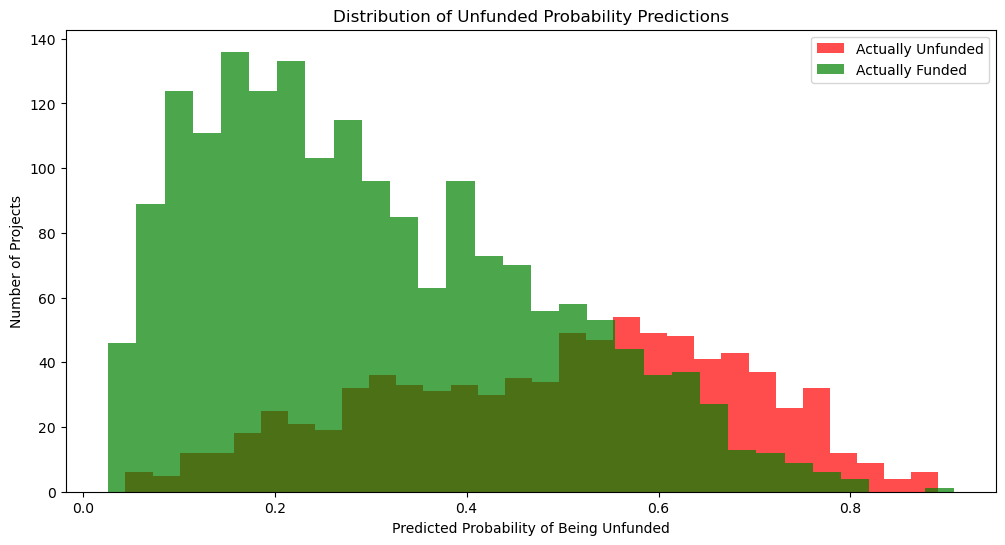

<Figure size 1000x800 with 0 Axes>

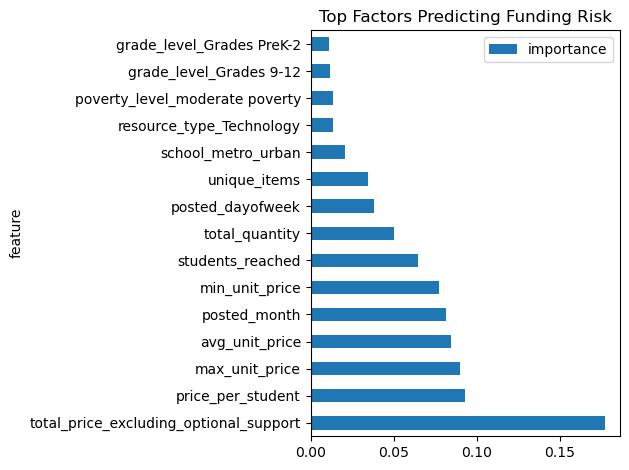

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_curve, auc, precision_recall_curve

#  1. DATA PREPROCESSING 
def load_and_preprocess(filepath):
    """Load and preprocess DonorsChoose data"""
    df = pd.read_csv(filepath)
    # Convert boolean columns
    for col in ['school_charter_t', 'school_magnet_t']:
        df[col] = df[col].astype(str).str.upper() == 'TRUE'
    
    # Add useful derived features
    df['price_per_student'] = df['total_price_excluding_optional_support'] / df['students_reached'].clip(lower=1)
    return df

# Load data
train = load_and_preprocess('C:/Users/zarin/Downloads/train_80.csv')
test = load_and_preprocess('C:/Users/zarin/Downloads/test_20.csv')



In [ ]:
#  2. FEATURE ENGINEERING 
categorical_cols = [
    'primary_focus_subject', 'primary_focus_area', 'school_metro',
    'grade_level', 'resource_type', 'poverty_level',
    'school_charter_t', 'school_magnet_t'
]

def encode_features(df):
    """One-hot encode categorical features and align columns"""
    return pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Process training data
train_encoded = encode_features(train)
X_train = train_encoded.drop('label', axis=1)
y_train = train_encoded['label']

# Process test data 
test_encoded = encode_features(test)
X_test = test_encoded.reindex(columns=X_train.columns, fill_value=0)
y_test = test['label']



In [ ]:
#  3. MODEL TRAINING 
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight={0: 2, 1: 1},  # Extra weight on unfunded projects
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


In [ ]:
#  4. EVALUATION 
y_pred = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]  # Probability of being funded

print("=== MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred, target_names=["Unfunded", "Funded"]))


In [ ]:
#  5. ACTIONABLE OUTPUT 
test['prob_unfunded'] = 1 - probs  # Convert to probability of being unfunded

# Flag top 10% highest risk projects
flagged_projects = test.sort_values('prob_unfunded', ascending=False).head(int(0.1 * len(test)))

# Add expert recommendations
def generate_recommendations(row):
    recommendations = []
    
    if row['prob_unfunded'] > 0.8:
        recommendations.append("URGENT: High risk of expiration")
    
    if row['poverty_level'] == 'highest poverty':
        recommendations.append("Highlight poverty context")
        
    if row['price_per_student'] > 25:
        recommendations.append("Suggest cost-saving alternatives")
        
    if row['resource_type'] == 'Technology':
        recommendations.append("Consider phased funding")
        
    if not recommendations:
        return "General presentation improvements"
    return " | ".join(recommendations)

flagged_projects['expert_recommendation'] = flagged_projects.apply(generate_recommendations, axis=1)

# Final output columns
output_columns = [
    'prob_unfunded', 'poverty_level', 'resource_type',
    'total_price_excluding_optional_support', 'price_per_student',
    'students_reached', 'expert_recommendation'
]

# Save 
flagged_projects[output_columns].sort_values('prob_unfunded', ascending=False)\
    .to_csv('C:/Users/zarin/Downloads/DonorsChoose_Expert_Review_List.csv', index=False)




=== PROCESS COMPLETE ===
Generated expert review list for 265 high-risk projects
Saved files:
- DonorsChoose_Expert_Review_List.csv
- probability_distribution.png
- feature_importance.png


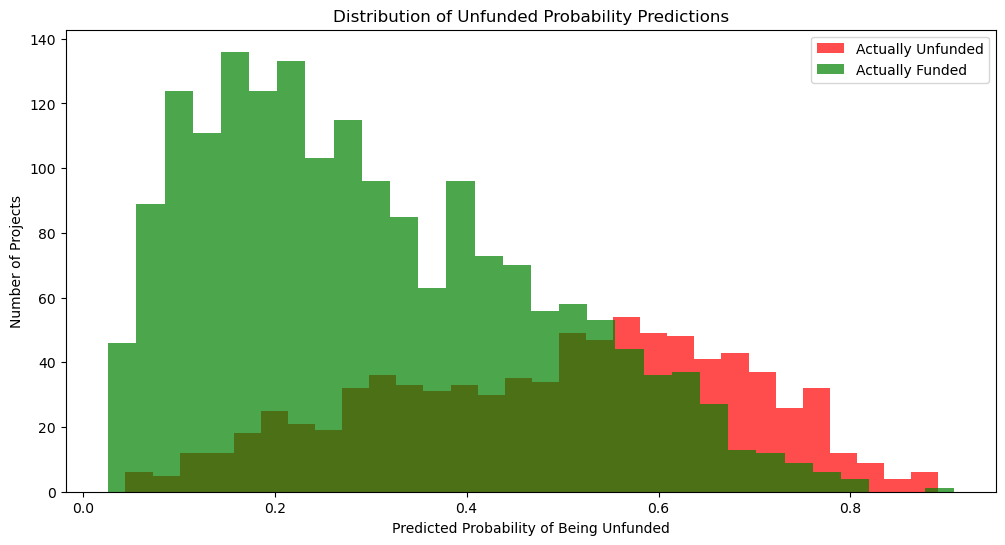

<Figure size 1000x800 with 0 Axes>

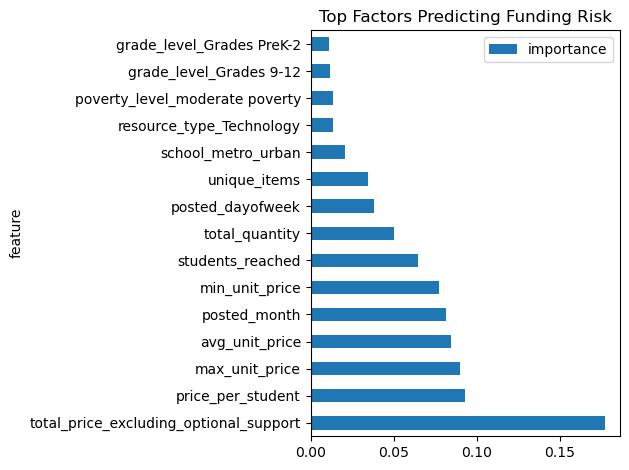

In [22]:
#  6. EXPLANATORY VISUALIZATIONS 
plt.figure(figsize=(12, 6))
plt.hist(1-probs[y_test==0], bins=30, alpha=0.7, label='Actually Unfunded', color='red')
plt.hist(1-probs[y_test==1], bins=30, alpha=0.7, label='Actually Funded', color='green')
plt.title('Distribution of Unfunded Probability Predictions')
plt.xlabel('Predicted Probability of Being Unfunded')
plt.ylabel('Number of Projects')
plt.legend()
plt.savefig('C:/Users/zarin/Downloads/probability_distribution.png')

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
feature_importance.head(15).plot.barh(x='feature', y='importance')
plt.title('Top Factors Predicting Funding Risk')
plt.tight_layout()
plt.savefig('C:/Users/zarin/Downloads/feature_importance.png')

print("\n=== PROCESS COMPLETE ===")
print(f"Generated expert review list for {len(flagged_projects)} high-risk projects")
print("Saved files:")
print("- DonorsChoose_Expert_Review_List.csv")
print("- probability_distribution.png")
print("- feature_importance.png")

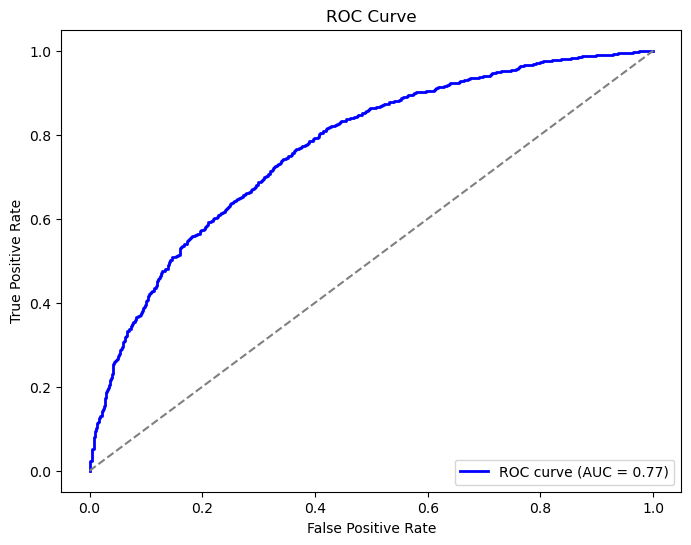

In [19]:
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()


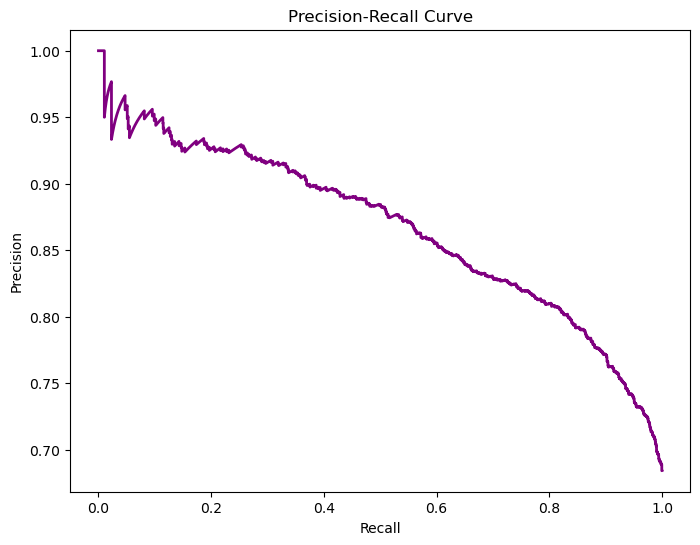

In [20]:
from sklearn.metrics import precision_recall_curve

# Compute Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, probs)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='purple', lw=2)
plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.show()
